slowa kluczowe: regresja logistyczna, regresja logistyczna wieloklasowa, klasyfikacja wieloklasowa, softmax,standaryzacja danych, macierz pomyłek

Regresja logistyczna wieloklasowa jest modelem klasyfikacyjnym, który oblicza prawdopodobieństwo przynależności obserwacji do każdej z możliwych klas. Dla każdej klasy model wyznacza osobny zestaw wag, a następnie wykorzystuje funkcję softmax, aby zamienić wyniki na wartości z przedziału [0,1], których suma wynosi 1. Klasa o największym prawdopodobieństwie jest wybierana jako wynik predykcji.

Uczenie modelu polega na dopasowaniu wag w taki sposób, aby minimalizować błąd klasyfikacji na danych treningowych, zazwyczaj metodami gradientowymi.

## import bibliotek

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [41]:
pokemonyMain = pd.read_csv("pokemon.csv")
pokemonyMain.head()

,name,pokemonid,formid,formname,gen,release,type1,type2,species,height,...,defense,spatk,spdef,speed,ev_hp,ev_attack,ev_defense,ev_spatk,ev_spdef,ev_speed
0,bulbasaur,bulbasaur,NaN,NaN,1,red-blue,grass,poison,Seed,0.7,...,49,65,65,45,NaN,NaN,NaN,1.0,NaN,NaN
1,ivysaur,ivysaur,NaN,NaN,1,red-blue,grass,poison,Seed,1.0,...,63,80,80,60,NaN,NaN,NaN,1.0,1.0,NaN
2,venusaur,venusaur,NaN,NaN,1,red-blue,grass,poison,Seed,2.0,...,83,100,100,80,NaN,NaN,NaN,2.0,1.0,NaN
3,venusaur-mega,venusaur,mega,Mega Venusaur,6,x-y,grass,poison,Seed,2.4,...,123,122,120,80,NaN,NaN,NaN,2.0,1.0,NaN
4,charmander,charmander,NaN,NaN,1,red-blue,fire,NaN,Lizard,0.6,...,43,60,50,65,NaN,NaN,NaN,NaN,NaN,1.0


## Podział pokemonów na grupy
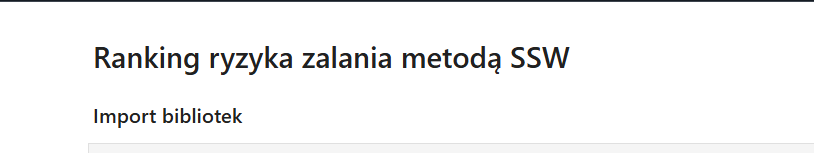

In [42]:
type_to_group = {
    "water": "sredniaki",
    "poison": "sredniaki",
    "grass": "sredniaki",
    "ice": "sredniaki",
    "normal": "sredniaki",
    "bug": "sredniaki",

    "dragon": "elita",

    "electric": "specjalni",
    "psychic": "specjalni",
    "fairy": "specjalni",
    "ghost": "specjalni",
    "fire": "specjalni",

    "fighting": "agresorzy",
    "dark": "agresorzy",
    "flying": "agresorzy",

    "ground": "grubole",
    "rock": "grubole",
    "steel": "grubole",
}

pokemonyMain["group"] = pokemonyMain["type1"].str.lower().map(type_to_group)
pokemonyMain = pokemonyMain.dropna(subset=["group"])
pokemonyMain["group"].value_counts()

group
sredniaki    580
specjalni    310
grubole      160
agresorzy    116
elita         49
Name: count, dtype: int64

In [43]:
pokemonyMain.head()

,name,pokemonid,formid,formname,gen,release,type1,type2,species,height,...,spatk,spdef,speed,ev_hp,ev_attack,ev_defense,ev_spatk,ev_spdef,ev_speed,group
0,bulbasaur,bulbasaur,NaN,NaN,1,red-blue,grass,poison,Seed,0.7,...,65,65,45,NaN,NaN,NaN,1.0,NaN,NaN,sredniaki
1,ivysaur,ivysaur,NaN,NaN,1,red-blue,grass,poison,Seed,1.0,...,80,80,60,NaN,NaN,NaN,1.0,1.0,NaN,sredniaki
2,venusaur,venusaur,NaN,NaN,1,red-blue,grass,poison,Seed,2.0,...,100,100,80,NaN,NaN,NaN,2.0,1.0,NaN,sredniaki
3,venusaur-mega,venusaur,mega,Mega Venusaur,6,x-y,grass,poison,Seed,2.4,...,122,120,80,NaN,NaN,NaN,2.0,1.0,NaN,sredniaki
4,charmander,charmander,NaN,NaN,1,red-blue,fire,NaN,Lizard,0.6,...,60,50,65,NaN,NaN,NaN,NaN,NaN,1.0,specjalni


In [44]:
pokemonyMain.to_csv("pokemonyMain_groups.csv", index=False)
pokemonyMain_regresja = pokemonyMain.copy()


## Zmienne
Wybieramy zestaw cech opisujacych statystyki oraz parametry Pokemonów na których będziemy operować

In [45]:
pokemonyMain_regresja = pokemonyMain_regresja.dropna(subset=[
    "weight",
    "catch_rate",
    "base_exp",
    "group"
])
cechy = pokemonyMain_regresja[[
    "hp",
    "attack",
    "defense",
    "spatk",
    "spdef",
    "speed",
    "height",
    "weight",
    "catch_rate",
    "base_exp",
    "egg_cycles"
]]
etykieta = pokemonyMain_regresja["group"]

## Podział danych na zbiór treningowy i testowy
Dane zostały podzielone na zbiór treningowy (70%) oraz testowy (30%) w celu oceny skuteczności modelu.

In [46]:
cecha_train_regresja, cecha_test_regresja, etykieta_train_regresja, etykieta_test_regresja = train_test_split(
    cechy,
    etykieta,
    test_size=0.3,
    random_state=42
)

In [47]:
cechy.isna().sum()

hp            0
attack        0
defense       0
spatk         0
spdef         0
speed         0
height        0
weight        0
catch_rate    0
base_exp      0
egg_cycles    0
dtype: int64

## Regresja logistyczna
Zastowaliśmy regresję logistyczną wieloklasową wraz ze standaryzacją danych.

In [48]:
modelRegresja = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, solver="lbfgs"))

trenowanie modelu


In [49]:
modelRegresja.fit(cecha_train_regresja, etykieta_train_regresja)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

## Macierz błędów klasyfikacji dla zbioru treningowego


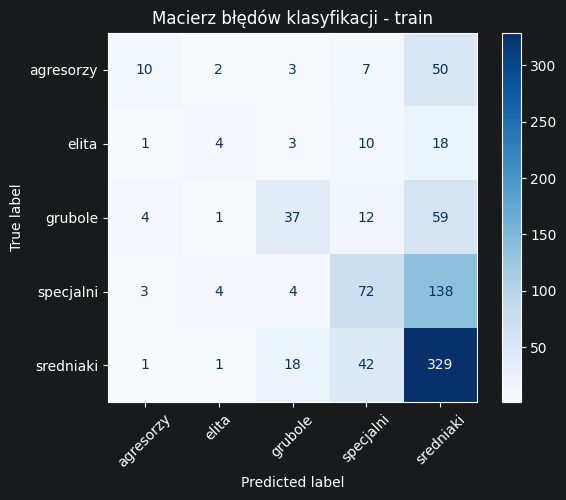

In [50]:
predykcja_train_regresja = modelRegresja.predict(cecha_train_regresja)
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_train_regresja,
    predykcja_train_regresja,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - train")
plt.savefig("confusion_matrix_train_regresja.png", dpi=300, bbox_inches="tight")
plt.show()

## Dokładność modelu zbiór - testowy

In [51]:
predykcja_test_regresja = modelRegresja.predict(cecha_test_regresja)
print("Accuracy:", accuracy_score(etykieta_test_regresja, predykcja_test_regresja))
procent_poprawnych = accuracy_score(etykieta_test_regresja, predykcja_test_regresja) * 100
print(f"Procent poprawnych wyników: {procent_poprawnych:.2f}%")


Accuracy: 0.5418994413407822
Procent poprawnych wyników: 54.19%


In [52]:
wyniki = cecha_test_regresja.copy()

wyniki["prawdziwa_grupa"] = etykieta_test_regresja.values
wyniki["przewidziana_grupa"] = predykcja_test_regresja

wyniki["pokemon"] = pokemonyMain_regresja.loc[cecha_test_regresja.index, "name"].values

print(wyniki[["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]].head(20))


           pokemon prawdziwa_grupa przewidziana_grupa
953      pheromosa       sredniaki          specjalni
247          yanma       sredniaki          sredniaki
260         pineco       sredniaki          sredniaki
155         horsea       sredniaki          sredniaki
566      rhyperior         grubole            grubole
549   lucario-mega       agresorzy          specjalni
803        flabebe       specjalni          sredniaki
58       vileplume       sredniaki          sredniaki
753       braviary       sredniaki          sredniaki
644         audino       sredniaki          sredniaki
613       oshawott       sredniaki          sredniaki
746      druddigon           elita          sredniaki
716       frillish       sredniaki          sredniaki
572        leafeon       sredniaki            grubole
380       meditite       agresorzy          sredniaki
70         persian       sredniaki          sredniaki
523       drifloon       specjalni          sredniaki
823        malamar       agr

## Macierz błędów klasyfikacji dla zbioru testowego


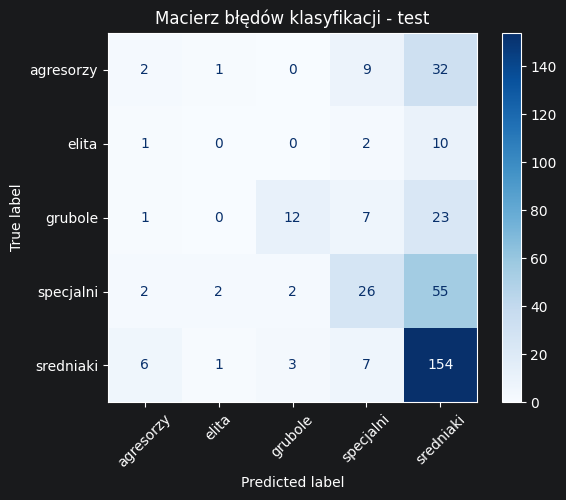

In [53]:
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_test_regresja,
    predykcja_test_regresja,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - test")
plt.savefig("confusion_matrix_test_regresja.png", dpi=300, bbox_inches="tight")
plt.show()

Jackowska, Beata (2011), Efekty interakcji między zmiennymi objaśniającymi w modelu logitowym w analizie zróżnicowania ryzyka zgonu, Przegląd Statystyczny, R. LVIII, z. 1–2

Zięba, M. (2019). Modele liniowe [materiały dydaktyczne, wykład RO_W4]. Politechnika Wrocławska.